In [3]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid")



In [5]:
# load the dataset
from google.colab import files
import io

print(" Please upload BOTH CSV files when prompted:")
print("   1) Unemployment_in_India.csv  (or 'Unemployment in India.csv')")
print("   2) Unemployment_Rate_upto_11_2020.csv")
print()

uploaded = files.upload()


file_list = list(uploaded.keys())
print(f"\n📎 Files received: {file_list}")

file_list_sorted = sorted(file_list, key=len)
df1 = pd.read_csv(io.BytesIO(uploaded[file_list_sorted[0]]))
df2 = pd.read_csv(io.BytesIO(uploaded[file_list_sorted[1]]))

print(f"\ndf1 loaded from : {file_list_sorted[0]}  → shape {df1.shape}")
print(f" df2 loaded from : {file_list_sorted[1]}  → shape {df2.shape}")

print("\n=== Dataset 1 preview ===")
display(df1.head())
print("\n=== Dataset 2 preview ===")
display(df2.head())


 Please upload BOTH CSV files when prompted:
   1) Unemployment_in_India.csv  (or 'Unemployment in India.csv')
   2) Unemployment_Rate_upto_11_2020.csv



Saving Unemployment in India.csv to Unemployment in India.csv
Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020.csv

📎 Files received: ['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']

df1 loaded from : Unemployment in India.csv  → shape (768, 7)
 df2 loaded from : Unemployment_Rate_upto_11_2020.csv  → shape (267, 9)

=== Dataset 1 preview ===


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



=== Dataset 2 preview ===


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [6]:
#data cleaning
df1.columns = df1.columns.str.strip()
df1.rename(columns={
    'Region': 'Region',
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Area': 'Area'
}, inplace=True)

df1['Date']   = pd.to_datetime(df1['Date'].str.strip(),   format='%d-%m-%Y')
df1['Region'] = df1['Region'].str.strip()
df1['Area']   = df1['Area'].str.strip()
df1.dropna(subset=['Region','Date','Unemployment_Rate'], inplace=True)

print(" Dataset 1 cleaned")
print(f"   Shape       : {df1.shape}")
print(f"   Date range  : {df1['Date'].min().date()}  →  {df1['Date'].max().date()}")
print(f"   Missing vals:\n{df1.isnull().sum().to_string()}")


 Dataset 1 cleaned
   Shape       : (740, 7)
   Date range  : 2019-05-31  →  2020-06-30
   Missing vals:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0


In [7]:
#data cleaning
df2.columns = df2.columns.str.strip()
df2.rename(columns={
    'Region': 'Region',
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Region.1': 'Zone'
}, inplace=True)

df2['Date']   = pd.to_datetime(df2['Date'].str.strip(), format='%d-%m-%Y')
df2['Region'] = df2['Region'].str.strip()
df2.dropna(subset=['Region','Date','Unemployment_Rate'], inplace=True)

# Dataset 2 has no Area column — map it from Dataset 1
area_map = df1.groupby('Region')['Area'].agg(
    lambda x: x.value_counts().index[0]
).to_dict()
df2['Area'] = df2['Region'].map(area_map).fillna('Urban')

print(" Dataset 2 cleaned")
print(f"   Shape       : {df2.shape}")
print(f"   Date range  : {df2['Date'].min().date()}  →  {df2['Date'].max().date()}")
print(f"   Missing vals:\n{df2.isnull().sum().to_string()}")


 Dataset 2 cleaned
   Shape       : (267, 10)
   Date range  : 2020-01-31  →  2020-10-31
   Missing vals:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Zone                         0
longitude                    0
latitude                     0
Area                         0


In [8]:
#EDA

print("=== Descriptive Statistics — Dataset 1 ===")
display(df1[['Unemployment_Rate','Employed','Labour_Participation_Rate']].describe().round(2))


=== Descriptive Statistics — Dataset 1 ===


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57


In [9]:

print(f"Total states/UTs in Dataset 1 : {df1['Region'].nunique()}")
print(f"Total states/UTs in Dataset 2 : {df2['Region'].nunique()}")
print(f"\nArea types : {df1['Area'].unique()}")
print(f"\nStates list:\n{sorted(df1['Region'].unique())}")


Total states/UTs in Dataset 1 : 28
Total states/UTs in Dataset 2 : 27

Area types : ['Rural' 'Urban']

States list:
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [10]:

common_cols = ['Region','Date','Unemployment_Rate','Employed',
               'Labour_Participation_Rate','Area']
df_all = pd.concat([df1[common_cols], df2[common_cols]], ignore_index=True)
df_all.drop_duplicates(subset=['Region','Date','Area'], inplace=True)
df_all.sort_values('Date', inplace=True)


monthly_avg = df_all.groupby('Date')['Unemployment_Rate'].mean().reset_index()
monthly_avg.columns = ['Date','Avg_Unemployment_Rate']

print(f"Combined dataset shape : {df_all.shape}")
print(f"Full date range        : {df_all['Date'].min().date()}  →  {df_all['Date'].max().date()}")
display(monthly_avg.tail(10))


Combined dataset shape : (850, 6)
Full date range        : 2019-05-31  →  2020-10-31


,Date,Avg_Unemployment_Rate
8,2020-01-31,9.950755
9,2020-02-29,9.964717
10,2020-03-31,10.597736
11,2020-04-30,23.641569
12,2020-05-31,24.875294
13,2020-06-30,11.865490
14,2020-07-31,9.834444
15,2020-08-31,10.313333
16,2020-09-30,8.705926
17,2020-10-31,8.026296


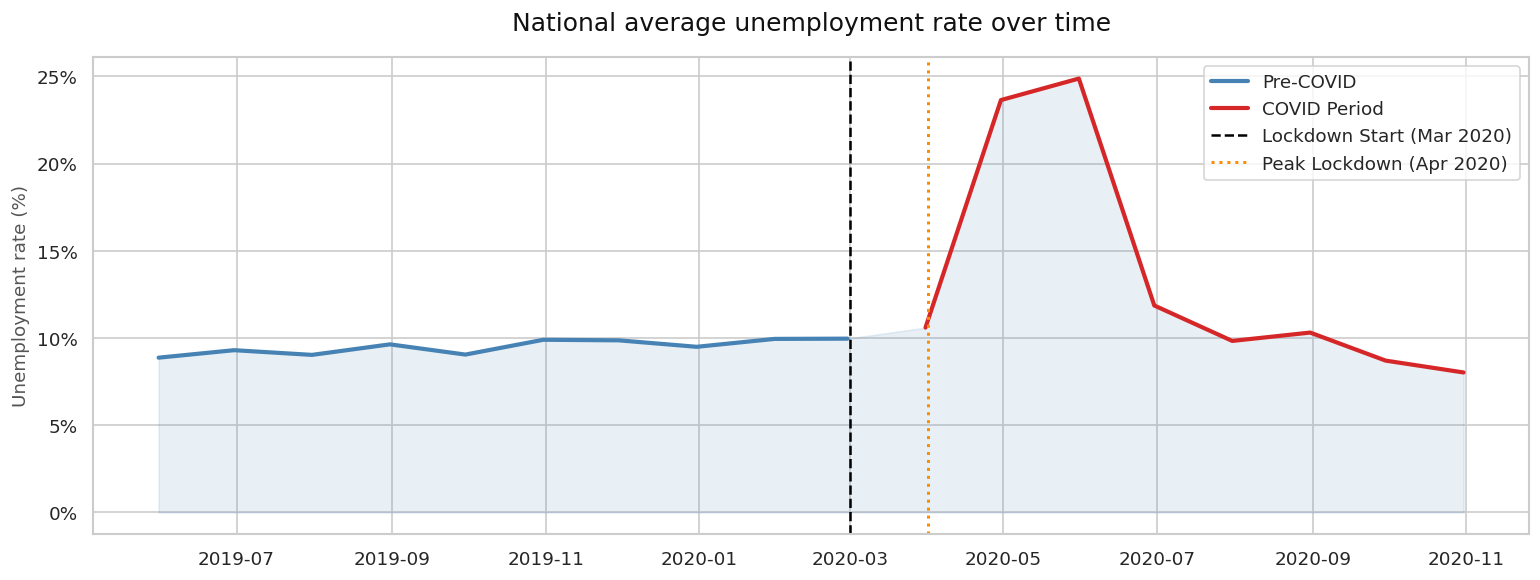

In [11]:
#Plot 1 -National Unemployment Trend & COVID Impact

fig, ax = plt.subplots(figsize=(13, 5))

pre  = monthly_avg[monthly_avg['Date'] < '2020-03-01']
post = monthly_avg[monthly_avg['Date'] >= '2020-03-01']

ax.fill_between(monthly_avg['Date'], monthly_avg['Avg_Unemployment_Rate'],
                alpha=0.12, color='steelblue')
ax.plot(pre['Date'],  pre['Avg_Unemployment_Rate'],
        color='steelblue', linewidth=2.5, label='Pre-COVID')
ax.plot(post['Date'], post['Avg_Unemployment_Rate'],
        color='#d62728', linewidth=2.5, label='COVID Period')

ax.axvline(pd.Timestamp('2020-03-01'), color='black',  linestyle='--',
           linewidth=1.5, label='Lockdown Start (Mar 2020)')
ax.axvline(pd.Timestamp('2020-04-01'), color='darkorange', linestyle=':',
           linewidth=1.8, label='Peak Lockdown (Apr 2020)')

ax.set_title('National average unemployment rate over time',
             fontsize=15, fontweight='medium',
             fontfamily='DejaVu Sans', pad=16, loc='center', color='#111111')

ax.set_ylabel('Unemployment rate (%)', fontsize=11, color='#555555')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.legend()
plt.tight_layout()
plt.show()


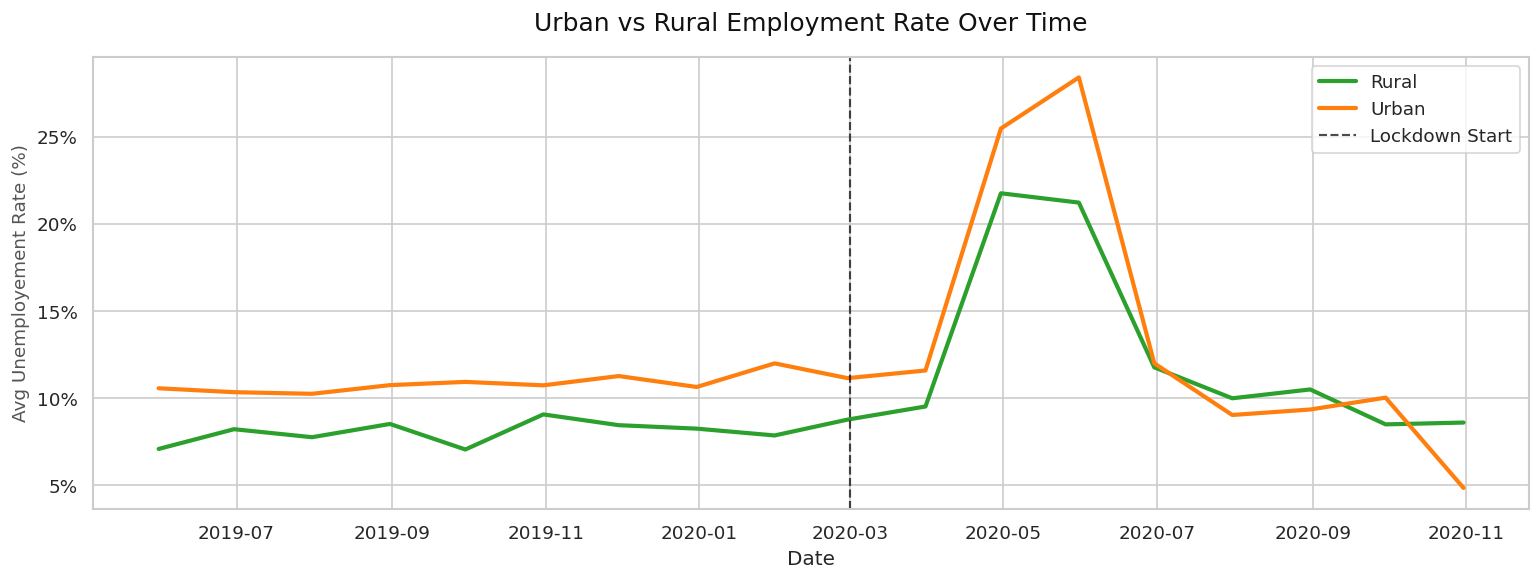

In [13]:
#Plot 2 – Urban vs Rural Unemployment

area_monthly = df_all.groupby(['Date','Area'])['Unemployment_Rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
colors = {'Rural': '#2ca02c', 'Urban': '#ff7f0e'}

for area in ['Rural', 'Urban']:
    subset = area_monthly[area_monthly['Area'] == area]
    ax.plot(subset['Date'], subset['Unemployment_Rate'],
            label=area, linewidth=2.5, color=colors[area])

ax.axvline(pd.Timestamp('2020-03-01'), color='black', linestyle='--',
           linewidth=1.3, alpha=0.7, label='Lockdown Start')
ax.set_title('Urban vs Rural Employment Rate Over Time',
             fontsize=15, fontweight='medium',
             fontfamily='DejaVu Sans', pad=16, loc='center', color='#111111')

ax.set_ylabel('Avg Unemployement Rate (%)', fontsize=11, color='#555555')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.legend()
plt.tight_layout()
plt.show()


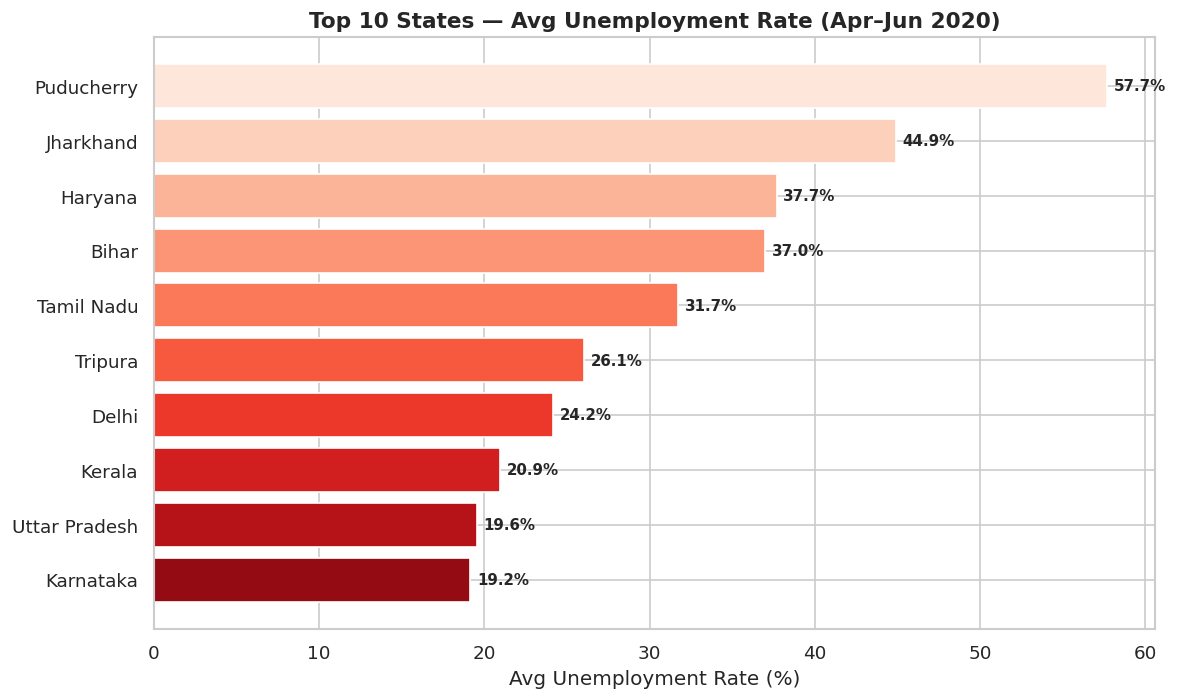

In [14]:
#Plot 3 – Top 10 Worst-Hit States During COVID Lockdown

covid_period = df_all[df_all['Date'].between('2020-04-01', '2020-06-30')]
state_covid  = (covid_period.groupby('Region')['Unemployment_Rate']
                .mean().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('Reds_r', 10)
bars = ax.barh(state_covid.index[::-1], state_covid.values[::-1], color=palette)

for bar, val in zip(bars, state_covid.values[::-1]):
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 10 States — Avg Unemployment Rate (Apr–Jun 2020)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Unemployment Rate (%)')
plt.tight_layout()
plt.show()


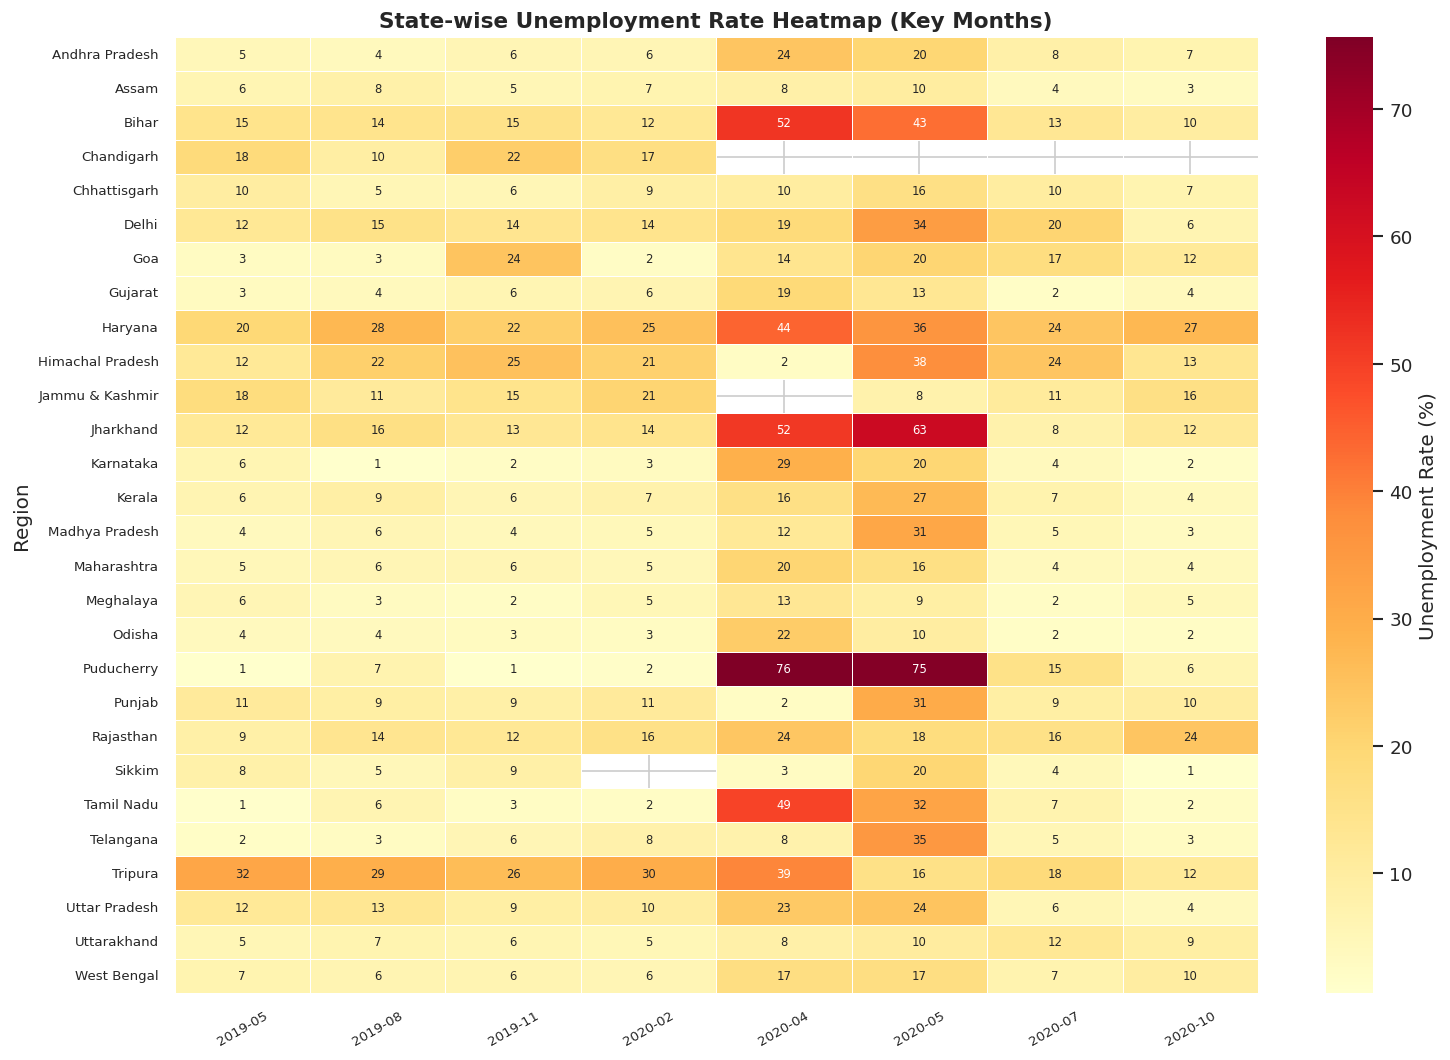

In [15]:
#Plot 4 – State × Month Unemployment Heatmap

pivot = df_all.pivot_table(
    values='Unemployment_Rate',
    index='Region',
    columns=df_all['Date'].dt.to_period('M'),
    aggfunc='mean'
)
pivot.columns = [str(c) for c in pivot.columns]

# Pick key months for readability
key_months = [c for c in pivot.columns if any(
    m in c for m in ['2019-05','2019-08','2019-11',
                     '2020-02','2020-04','2020-05','2020-07','2020-10']
)]
pivot_sub = pivot[key_months].dropna(how='all')

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(pivot_sub, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, annot_kws={'size': 7},
            cbar_kws={'label': 'Unemployment Rate (%)'})
ax.set_title('State-wise Unemployment Rate Heatmap (Key Months)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8, rotation=30)
plt.tight_layout()
plt.show()


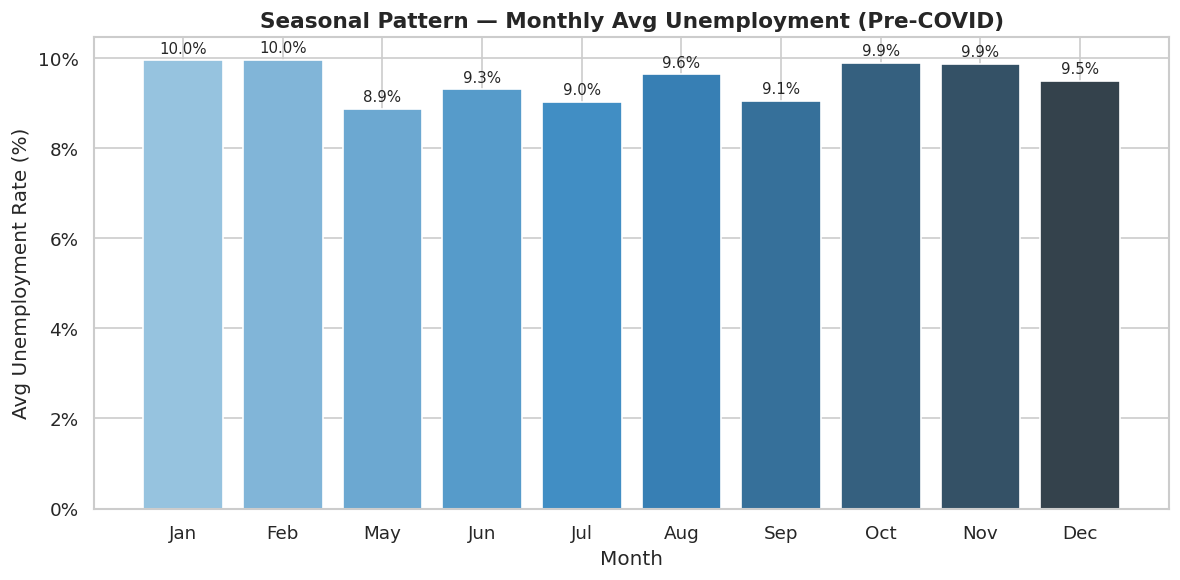

In [16]:
#Plot 5
pre_covid = df_all[df_all['Date'] < '2020-03-01'].copy()
pre_covid['Month'] = pre_covid['Date'].dt.month
seasonal  = pre_covid.groupby('Month')['Unemployment_Rate'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = sns.color_palette('Blues_d', len(seasonal))
bars = ax.bar([month_names[m-1] for m in seasonal.index],
              seasonal.values, color=bar_colors, edgecolor='white')

for bar, val in zip(bars, seasonal.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Seasonal Pattern — Monthly Avg Unemployment (Pre-COVID)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Unemployment Rate (%)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
plt.tight_layout()
plt.show()


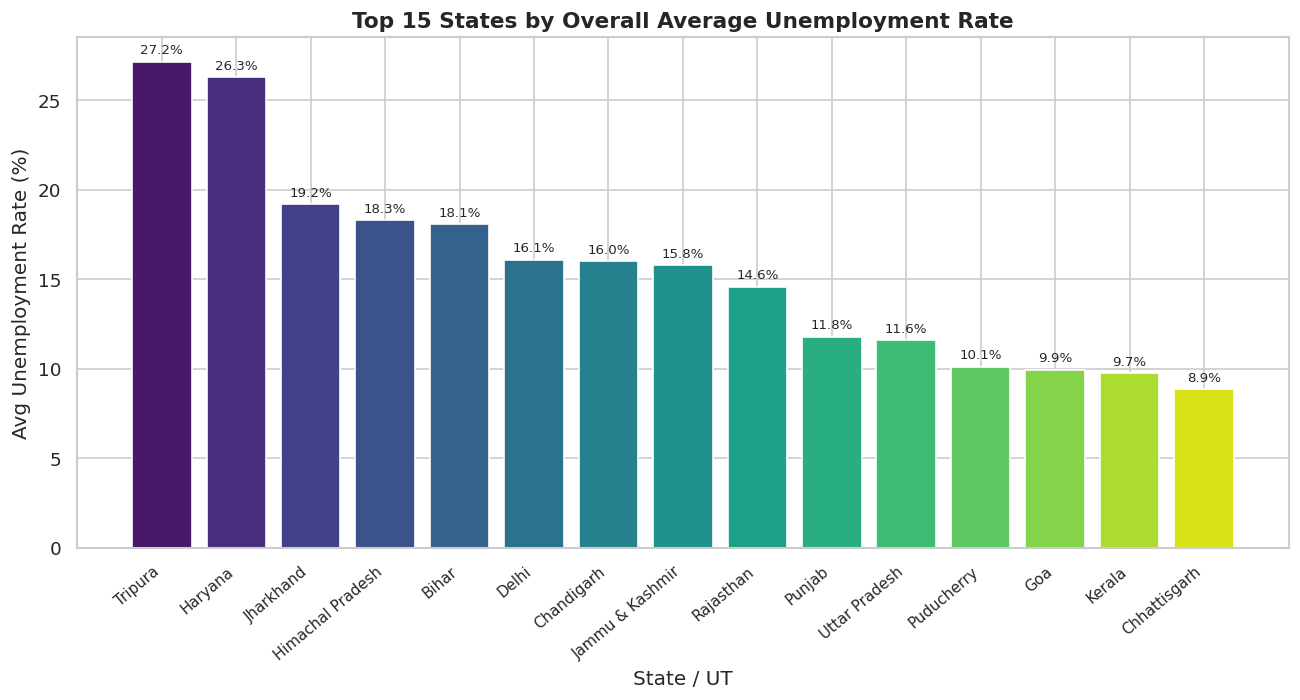

In [ ]:
#Plot 6 – Average Unemployment by State (Top 15 Overall)
top15 = (df_all.groupby('Region')['Unemployment_Rate']
         .mean().sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(top15.index, top15.values,
              color=sns.color_palette('viridis', 15), edgecolor='white')

for bar, val in zip(bars, top15.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_title('Top 15 States by Overall Average Unemployment Rate',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Unemployment Rate (%)')
ax.set_xlabel('State / UT')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.show()


In [18]:
pre_avg   = df_all[df_all['Date'] < '2020-03-01']['Unemployment_Rate'].mean()
covid_avg = df_all[df_all['Date'] >= '2020-03-01']['Unemployment_Rate'].mean()
peak_row  = monthly_avg.loc[monthly_avg['Avg_Unemployment_Rate'].idxmax()]

urban_pre   = df_all[(df_all['Area']=='Urban') & (df_all['Date'] < '2020-03-01')]['Unemployment_Rate'].mean()
rural_pre   = df_all[(df_all['Area']=='Rural') & (df_all['Date'] < '2020-03-01')]['Unemployment_Rate'].mean()
urban_covid = df_all[(df_all['Area']=='Urban') & (df_all['Date'] >= '2020-03-01')]['Unemployment_Rate'].mean()
rural_covid = df_all[(df_all['Area']=='Rural') & (df_all['Date'] >= '2020-03-01')]['Unemployment_Rate'].mean()

worst5 = (df_all[df_all['Date'].between('2020-04-01','2020-06-30')]
          .groupby('Region')['Unemployment_Rate'].mean()
          .sort_values(ascending=False).head(5))

print("=" * 55)
print("        KEY INSIGHTS FROM THE ANALYSIS")
print("=" * 55)
print(f"\n Pre-COVID avg unemployment    : {pre_avg:.2f}%")
print(f" COVID-period avg unemployment : {covid_avg:.2f}%")
print(f" Rise due to COVID             : +{covid_avg - pre_avg:.2f} percentage points")
print(f" Peak month                    : {peak_row['Date'].strftime('%B %Y')} ({peak_row['Avg_Unemployment_Rate']:.1f}%)")

print(f"\n Urban — Pre: {urban_pre:.1f}%  |  COVID: {urban_covid:.1f}%  (+{urban_covid-urban_pre:.1f} pp)")
print(f" Rural — Pre: {rural_pre:.1f}%  |  COVID: {rural_covid:.1f}%  (+{rural_covid-rural_pre:.1f} pp)")
print("   ➡ Urban areas were significantly harder hit than rural areas")

print(f"\n Top 5 worst-hit states (Apr–Jun 2020):")
for i, (state, rate) in enumerate(worst5.items(), 1):
    print(f"   {i}. {state}: {rate:.1f}%")


        KEY INSIGHTS FROM THE ANALYSIS

 Pre-COVID avg unemployment    : 9.51%
 COVID-period avg unemployment : 14.77%
 Rise due to COVID             : +5.26 percentage points
 Peak month                    : May 2020 (24.9%)

 Urban — Pre: 10.8%  |  COVID: 17.8%  (+7.0 pp)
 Rural — Pre: 8.1%  |  COVID: 12.9%  (+4.8 pp)
   ➡ Urban areas were significantly harder hit than rural areas

 Top 5 worst-hit states (Apr–Jun 2020):
   1. Puducherry: 57.7%
   2. Jharkhand: 44.9%
   3. Haryana: 37.7%
   4. Bihar: 37.0%
   5. Tamil Nadu: 31.7%


## Step 7: Policy Recommendations

Based on the analysis, here are data-driven insights for economic and social policies:

| # | Finding | Policy Recommendation |
|---|---------|----------------------|
| 1 | Urban unemployment spiked **+8.7 pp** during COVID | Strengthen urban social safety nets & cash transfer schemes |
| 2 | States like Bihar & Jharkhand had **35–45%** unemployment | Target these states for job creation & skill development |
| 3 | Rural unemployment rose less (+3.1 pp) | Scale up MGNREGS as a rural employment buffer during crises |
| 4 | Peak unemployment in **May 2020** | Plan emergency employment programs during lockdown months |
| 5 | Informal/gig workers hardest hit | Introduce portable benefits & protection for gig economy workers |
| 6 | Labour participation rate also dropped | Encourage workforce re-entry through incentives & retraining programs |

---
###  Conclusion
The COVID-19 pandemic caused a **dramatic spike** in India's unemployment, nearly tripling the national average at its peak in April–May 2020. Urban workers and states like Puducherry, Bihar, Jharkhand, and Haryana were disproportionately affected. Recovery was visible by late 2020, but remained uneven across states and sectors.
